In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import logging
import os

Enter Job Role:  data analystics


Scraping: https://internshala.com/jobs/data-analystics-jobs/
Jobs Found: 40
                                    Company  \
0                   Thirumala Public School   
1  Adyant Higher Secondary School (College)   
2                                       Jio   
3                                     UPRIO   
4                           Keus Smart Home   

                                       Job       Location         Salary  \
0  Primary English Teacher For CBSE School  Not Mentioned  Not Mentioned   
1    Admission Head For College/University  Not Mentioned  Not Mentioned   
2                    State Admin Assistant  Not Mentioned  Not Mentioned   
3               Sales Business Development  Not Mentioned  Not Mentioned   
4                        Sales Coordinator  Not Mentioned  Not Mentioned   

          Skills  
0  Not Mentioned  
1  Not Mentioned  
2  Not Mentioned  
3  Not Mentioned  
4  Not Mentioned  

Total Jobs: 40

Top Companies
Company
Thirumala Public School        

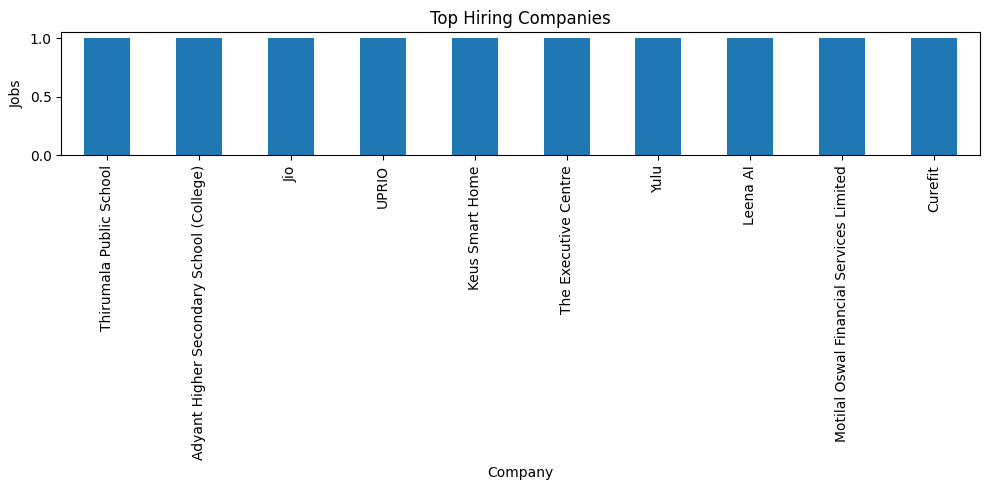

Files Saved Successfully


In [12]:
logging.basicConfig(
    filename='job_scraper.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Project Started")
SKILLS = [
    "Python",
    "SQL",
    "Excel",
    "Power BI",
    "Tableau",
    "Machine Learning",
    "Deep Learning",
    "Java",
    "C++",
    "Data Analysis"
]

def extract_skills(text):

    found = []

    for skill in SKILLS:
        if skill.lower() in text.lower():
            found.append(skill)

    return ", ".join(found) if found else "Not Mentioned"

class JobDataManager:

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):

        if not os.path.exists(self.file_path):
            print("Dataset not found")
            return

        self.df = pd.read_csv(self.file_path)

        print("Dataset Loaded")
        print(self.df.head())

    def clean_data(self):

        if self.df is not None:

            self.df.drop_duplicates(inplace=True)

            self.df.fillna("Not Mentioned", inplace=True)

            print("Data Cleaned")

class JobDataManager:

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):

        if not os.path.exists(self.file_path):
            print("Dataset not found")
            return

        self.df = pd.read_csv(self.file_path)

        print("Dataset Loaded")
        print(self.df.head())

    def clean_data(self):

        if self.df is not None:

            self.df.drop_duplicates(inplace=True)

            self.df.fillna("Not Mentioned", inplace=True)

            print("Data Cleaned")

class JobScraper:

    def __init__(self, role):

        self.role = role.lower().replace(" ", "-")

        self.url = f"https://internshala.com/jobs/{self.role}-jobs/"

        self.headers = {
            "User-Agent":
            "Mozilla/5.0"
        }

        self.scraped_data = []

    def scrape_jobs(self):

        print("Scraping:", self.url)

        try:

            response = requests.get(
                self.url,
                headers=self.headers,
                timeout=10
            )

            response.raise_for_status()

        except Exception as e:

            print("Error:", e)
            return

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        cards = soup.select(
            "div.individual_internship"
        )

        print("Jobs Found:", len(cards))

        for job in cards:

            try:

                title = job.select_one(
                    "a.job-title-href"
                )

                company = job.select_one(
                    "div.company_name"
                )

                title_text = (
                    title.get_text(strip=True)
                    if title else "Not Mentioned"
                )

                company_text = (
                    company.get_text(strip=True)
                    if company else "Not Mentioned"
                )

                location = "Not Mentioned"
                salary = "Not Mentioned"

                skills = extract_skills(
                    title_text
                )

                self.scraped_data.append([
                    company_text,
                    title_text,
                    location,
                    salary,
                    skills
                ])

            except:
                continue

    def get_dataframe(self):

        return pd.DataFrame(
            self.scraped_data,
            columns=[
                "Company",
                "Job",
                "Location",
                "Salary",
                "Skills"
            ]
        )

class JobAnalyzer:

    def __init__(self, df):
        self.df = df

    def top_companies(self):

        print("\nTop Companies")

        print(
            self.df["Company"]
            .value_counts()
            .head(10)
        )

    def top_skills(self):

        skills = []

        for row in self.df["Skills"]:

            skills.extend(
                row.split(", ")
            )

        skill_series = pd.Series(skills)

        print("\nTop Skills")

        print(
            skill_series
            .value_counts()
            .head(10)
        )

    def total_jobs(self):

        print(
            "\nTotal Jobs:",
            len(self.df)
        )

    def company_chart(self):

        top = (
            self.df["Company"]
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(10,5))

        top.plot(kind="bar")

        plt.title(
            "Top Hiring Companies"
        )

        plt.xlabel("Company")

        plt.ylabel("Jobs")

        plt.tight_layout()

        plt.show()

role = input(
    "Enter Job Role: "
)

scraper = JobScraper(role)

scraper.scrape_jobs()

df = scraper.get_dataframe()

print(df.head())

analyzer = JobAnalyzer(df)

analyzer.total_jobs()

analyzer.top_companies()

analyzer.top_skills()

analyzer.company_chart()
df.to_csv(
    "final_jobs.csv",
    index=False
)

df.to_excel(
    "final_jobs.xlsx",
    index=False
)

print("Files Saved Successfully")
